In [11]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

keras.utils.set_random_seed(42)

(x_train,y_train),(x_test,y_test)=keras.datasets.fashion_mnist.load_data()

labels = ["T-shirt/top",
          "Trouser",
          "Pullover",
          "Dress",
          "Coat",
          "Sandal",
          "Shirt",
          "Sneaker",
          "Bag",
          "Ankle boot"]

x_train=x_train/255.0
x_test=x_test/255.0
x_train= np.expand_dims(x_train,-1)
x_test=np.expand_dims(x_test,-1)
x_train.shape


(60000, 28, 28, 1)

In [12]:
input= keras.Input(shape=x_train.shape[1:])

# first conv layer
x= keras.layers.Conv2D(32,kernel_size=(3,3), activation='relu',name='Conv1')(input)
x= keras.layers.Conv2D(32,kernel_size=(3,3), activation='relu',name='Conv2')(x)

x=keras.layers.MaxPool2D()(x)

# second conv layer

x= keras.layers.Conv2D(64,kernel_size=(3,3),activation='relu', name="Conv3")(x)
x= keras.layers.Conv2D(64,kernel_size=(3,3),activation='relu', name="Conv4")(x)

x=keras.layers.MaxPool2D()(x)


x=keras.layers.Flatten()(x)

x=keras.layers.Dense(256,activation='relu')(x)

output= keras.layers.Dense(10, activation='softmax')(x)

model=keras.Model(input,output)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv4 (Conv2D)                  │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329,962 (1.26 MB)

 Trainable params: 329,962 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
keras.utils.plot_model(model, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [14]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=2,
    restore_best_weights=True
)


model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

history=model.fit(x_train, y_train, batch_size=64, epochs=10, validation_split=0.2,callbacks=[early_stop])

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 37s 48ms/step - accuracy: 0.8114 - loss: 0.5137 - val_accuracy: 0.8841 - val_loss: 0.3247
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 35s 46ms/step - accuracy: 0.8903 - loss: 0.2973 - val_accuracy: 0.8995 - val_loss: 0.2716
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 35s 46ms/step - accuracy: 0.9106 - loss: 0.2437 - val_accuracy: 0.9099 - val_loss: 0.2489
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 34s 46ms/step - accuracy: 0.9246 - loss: 0.2082 - val_accuracy: 0.9138 - val_loss: 0.2473
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.9354 - loss: 0.1790 - val_accuracy: 0.9153 - val_loss: 0.2492
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 35s 46ms/step - accuracy: 0.9463 - loss: 0.1520 - val_accuracy: 0.9156 - val_loss: 0.2601
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.9546 - loss: 0.1280 - val_accuracy: 0.9094 - val_loss: 0.3089
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.9612 - loss: 0.1095 - 

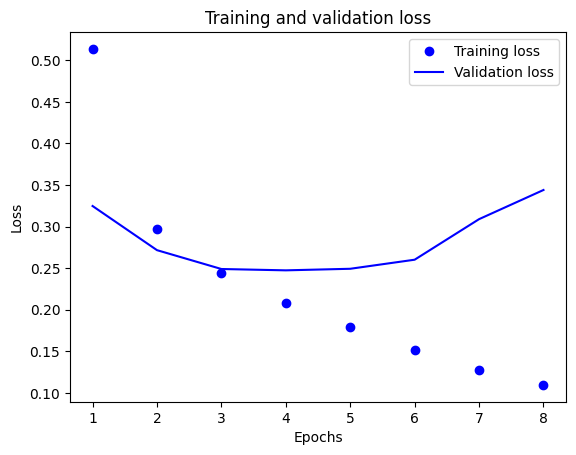

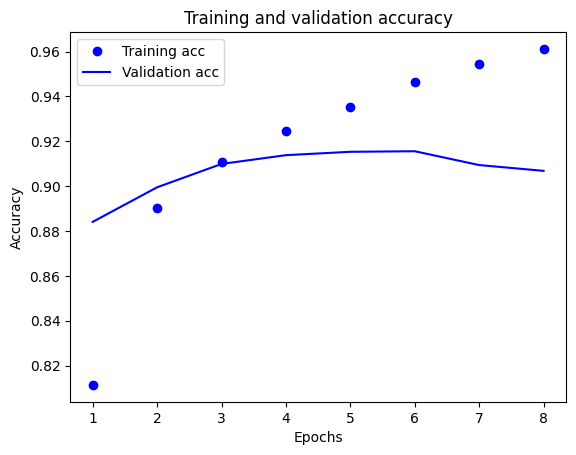

In [15]:
def plot_loss_curves(history):
  plt.clf()
  history_dict = history.history
  loss_values = history_dict["loss"]
  val_loss_values = history_dict["val_loss"]
  epochs = range(1, len(loss_values) + 1)
  plt.plot(epochs, loss_values, "bo", label="Training loss")
  plt.plot(epochs, val_loss_values, "b", label="Validation loss")
  plt.title("Training and validation loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

def plot_acc_curves(history):
  plt.clf()
  history_dict = history.history
  acc = history_dict["accuracy"]
  val_acc = history_dict["val_accuracy"]
  epochs = range(1, len(acc) + 1)
  plt.plot(epochs, acc, "bo", label="Training acc")
  plt.plot(epochs, val_acc, "b", label="Validation acc")
  plt.title("Training and validation accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.show()

plot_loss_curves(history)
plot_acc_curves(history)

In [16]:
score = model.evaluate(x_test, y_test)
score


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9134 - loss: 0.2767


[0.2766922414302826, 0.9133999943733215]